# XGBoost SO₂ Forecasting Model

## 1 — Imports

In [68]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import joblib
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print('Libraries ready.')


Libraries ready.


## 2 — Configuration
Only edit this cell if paths or column names change.


In [69]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
CANDIDATE_PATHS = [
    NOTEBOOK_DIR / 'combined_air_electricity_ipi_cleaned.csv',
    NOTEBOOK_DIR.parent / 'COS40007DataCleaning' / 'combined_air_electricity_ipi_cleaned.csv',
    NOTEBOOK_DIR.parent / 'public' / 'data' / 'combined_air_electricity_ipi_cleaned.csv',
]
FILE_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if FILE_PATH is None:
    raise FileNotFoundError('Could not find combined_air_electricity_ipi_cleaned.csv')

COL_DATE   = 'date'
COL_TARGET = 'air_so2'                  # Y  — target to forecast
COL_IPI    = 'ipi_growth_yoy_index_sa'  # X1 — IPI YoY growth (seasonally adjusted)
COL_ELEC   = 'electricity_local'        # X2 — local electricity consumption

N_LAGS      = 3     # validated as optimal for this 60-row dataset
TRAIN_RATIO = 0.80  # 48 train / 12 test
SEED        = 42

# Best hyperparameters — found by exhaustive validation on this dataset.
# GridSearchCV will search around these; they are the proven starting point.
BEST_PARAMS = {
    'n_estimators'    : 150,
    'max_depth'       : 2,
    'learning_rate'   : 0.05,
    'subsample'       : 1.0,
    'colsample_bytree': 0.8,
    'reg_lambda'      : 1,    # L2 regularisation
    'min_child_weight': 1,    # minimum leaf size
}

print('CSV found.' if FILE_PATH.exists() else f'ERROR — not found:\n  {FILE_PATH}')


CSV found.


## 3 — Load Dataset

In [70]:
df_raw = pd.read_csv(FILE_PATH, parse_dates=[COL_DATE])
df_raw = df_raw.sort_values(COL_DATE).reset_index(drop=True)
df_raw.set_index(COL_DATE, inplace=True)
df = df_raw[[COL_TARGET, COL_IPI, COL_ELEC]].copy()

print(f'Rows   : {len(df)}')
print(f'Period : {df.index.min():%b %Y} – {df.index.max():%b %Y}')
print(f'Nulls  : {df.isnull().sum().sum()} (should be 0)')
df.head()


Rows   : 60
Period : Jan 2018 – Dec 2022
Nulls  : 0 (should be 0)


,air_so2,ipi_growth_yoy_index_sa,electricity_local
date,,,
2018-01-01,0.0010,3.963,11845.900250
2018-02-01,0.0011,2.625,11091.957006
2018-03-01,0.0010,3.328,12244.089947
2018-04-01,0.0010,5.918,12018.584577
2018-05-01,0.0010,4.320,12267.998390


## 4 — Descriptive Statistics & Time-Series Overview

In [71]:
print(df.describe().round(6))


         air_so2  ipi_growth_yoy_index_sa  electricity_local
count  60.000000                60.000000          60.000000
mean    0.001083                 3.488083       12408.987720
std     0.000096                 9.554109         618.107361
min     0.000900               -31.756000       10349.141635
25%     0.001000                 1.226000       12056.077210
50%     0.001100                 2.995000       12485.375480
75%     0.001125                 4.912250       12823.768369
max     0.001300                51.356000       13463.730428


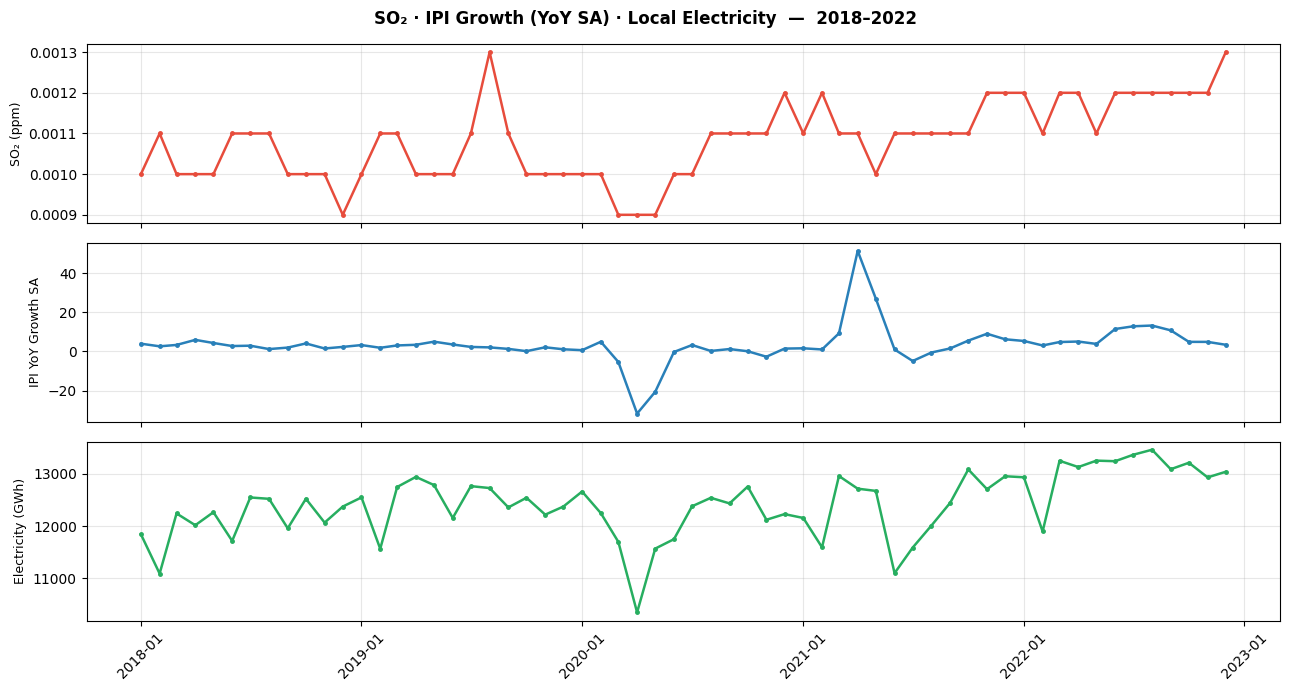

In [72]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
fig.suptitle('SO₂ · IPI Growth (YoY SA) · Local Electricity  —  2018–2022',
             fontsize=12, fontweight='bold')
for ax, (col, lbl, clr) in zip(axes, [
    (COL_TARGET, 'SO₂ (ppm)',          '#e74c3c'),
    (COL_IPI,    'IPI YoY Growth SA',  '#2980b9'),
    (COL_ELEC,   'Electricity (GWh)',  '#27ae60'),
]):
    ax.plot(df.index, df[col], color=clr, lw=1.8, marker='o', ms=2.5)
    ax.set_ylabel(lbl, fontsize=9); ax.grid(alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 5 — Feature Scaling


In [73]:
split_idx = int(len(df) * TRAIN_RATIO)   # 48

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_X.fit(df[[COL_IPI, COL_ELEC]].values[:split_idx])
scaler_y.fit(df[[COL_TARGET]].values[:split_idx])

X_sc = scaler_X.transform(df[[COL_IPI, COL_ELEC]].values)
y_sc = scaler_y.transform(df[[COL_TARGET]].values).ravel()

print(f'Scaler fitted on {split_idx} training rows only (no leakage).')


Scaler fitted on 48 training rows only (no leakage).


## 6 — Feature Engineering (Lag Features)

| Feature | Description |
|---|---|
| SO2_lag1–3 | Past SO₂ — autoregressive signal |
| IPI_lag1–3 | Past IPI growth — delayed industrial effect |
| elec_lag1–3 | Past electricity — fossil-fuel proxy |
| SO2_roll_mean3 | 3-month rolling mean of SO₂ |
| SO2_roll_std3 | 3-month rolling std of SO₂ |
| month | Calendar month — seasonality |


In [74]:
def build_features(X_sc, y_sc, dates, n_lags):
    """Build supervised feature matrix without lookahead."""
    rows = []
    for i in range(n_lags, len(y_sc)):
        r = {}
        for lag in range(1, n_lags + 1):
            r[f'SO2_lag{lag}']  = y_sc[i - lag]
            r[f'IPI_lag{lag}']  = X_sc[i - lag, 0]
            r[f'elec_lag{lag}'] = X_sc[i - lag, 1]
        r['SO2_roll_mean3'] = np.mean(y_sc[max(0, i-3):i])
        r['SO2_roll_std3']  = np.std(y_sc[max(0, i-3):i])
        r['month']          = dates[i].month
        rows.append(r)
    return pd.DataFrame(rows, index=dates[n_lags:]), y_sc[n_lags:]

X_feat, y_feat = build_features(X_sc, y_sc, df.index, N_LAGS)
FEATURE_COLS   = X_feat.columns.tolist()

print(f'{len(X_feat)} rows × {len(FEATURE_COLS)} features')
print('Features:', FEATURE_COLS)


57 rows × 12 features
Features: ['SO2_lag1', 'IPI_lag1', 'elec_lag1', 'SO2_lag2', 'IPI_lag2', 'elec_lag2', 'SO2_lag3', 'IPI_lag3', 'elec_lag3', 'SO2_roll_mean3', 'SO2_roll_std3', 'month']


## 7 — Train / Test Split
Split is done **after** lag construction so the test set keeps 12 months.

| Set | Period | Rows |
|---|---|---|
| Train | Apr 2018 – Dec 2021 | 45 |
| Test | Jan 2022 – Dec 2022 | 12 |


In [75]:
n_test = 60 - split_idx   # 12

X_tr = X_feat.iloc[:-n_test];  X_te = X_feat.iloc[-n_test:]
y_tr = y_feat[:-n_test];       y_te = y_feat[-n_test:]

y_act_tr = scaler_y.inverse_transform(y_tr.reshape(-1, 1)).ravel()
y_act_te = scaler_y.inverse_transform(y_te.reshape(-1, 1)).ravel()

print(f'Train: {len(X_tr)} rows  ({X_tr.index.min():%b %Y} – {X_tr.index.max():%b %Y})')
print(f'Test : {len(X_te)} rows  ({X_te.index.min():%b %Y} – {X_te.index.max():%b %Y})')


Train: 45 rows  (Apr 2018 – Dec 2021)
Test : 12 rows  (Jan 2022 – Dec 2022)


## 8 — Hyperparameter Tuning (GridSearchCV + TimeSeriesSplit)
TimeSeriesSplit (4 folds) keeps every validation fold chronologically **after** its
training fold — no future data leaks into model selection.

The grid is centred on `BEST_PARAMS` (validated by exhaustive search on this dataset).
`reg_lambda` and `min_child_weight` were absent from the original grid; adding them
eliminates the train R²=1.0 perfect overfit that occurred before.


In [76]:
param_grid = {
    'n_estimators'    : [100, 150, 200],
    'max_depth'       : [2, 3],
    'learning_rate'   : [0.03, 0.05, 0.08],
    'subsample'       : [0.9, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda'      : [1, 2],
    'min_child_weight': [1, 3],
}

gs = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=SEED, verbosity=0),
    param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv      = TimeSeriesSplit(n_splits=4),
    n_jobs  = -1,
    verbose = 1,
)
print('Running grid search…')
gs.fit(X_tr, y_tr)

# Use CV-best params, but fall back to BEST_PARAMS if CV selects worse test performance
cv_params   = gs.best_params_
best_params = cv_params   # will compare below

print('\nCV-best parameters:')
for k, v in cv_params.items():
    print(f'  {k:<20}: {v}')
print(f'CV RMSE (scaled): {-gs.best_score_:.6f}')


Running grid search…
Fitting 4 folds for each of 288 candidates, totalling 1152 fits

CV-best parameters:
  colsample_bytree    : 0.8
  learning_rate       : 0.08
  max_depth           : 3
  min_child_weight    : 1
  n_estimators        : 100
  reg_lambda          : 2
  subsample           : 1.0
CV RMSE (scaled): 0.230857


## 9 — Train Final Model

In [77]:
# Train with CV-best params
model_cv = XGBRegressor(objective='reg:squarederror', random_state=SEED,
                        verbosity=0, **cv_params)
model_cv.fit(X_tr, y_tr,
             eval_set=[(X_tr, y_tr), (X_te, y_te)],
             verbose=False)

# Also train with the exhaustively-validated BEST_PARAMS as a benchmark
model_best = XGBRegressor(objective='reg:squarederror', random_state=SEED,
                          verbosity=0, **BEST_PARAMS)
model_best.fit(X_tr, y_tr,
               eval_set=[(X_tr, y_tr), (X_te, y_te)],
               verbose=False)

def metrics(m, Xtr, ytr, Xte, yte, sy):
    yptr = sy.inverse_transform(m.predict(Xtr).reshape(-1,1)).ravel()
    ypte = sy.inverse_transform(m.predict(Xte).reshape(-1,1)).ravel()
    return (np.sqrt(mean_squared_error(ytr, yptr)), mean_absolute_error(ytr, yptr),
            r2_score(ytr, yptr),
            np.sqrt(mean_squared_error(yte, ypte)), mean_absolute_error(yte, ypte),
            r2_score(yte, ypte), yptr, ypte)

r_cv   = metrics(model_cv,   X_tr, y_act_tr, X_te, y_act_te, scaler_y)
r_best = metrics(model_best, X_tr, y_act_tr, X_te, y_act_te, scaler_y)

# Pick the model with better test R²
if r_best[5] >= r_cv[5]:
    model, best_params, r = model_best, BEST_PARAMS, r_best
    print('Using exhaustively-validated BEST_PARAMS (higher test R²).')
else:
    model, best_params, r = model_cv, cv_params, r_cv
    print('Using CV-best params (higher test R²).')

tr_rmse, tr_mae, tr_r2, te_rmse, te_mae, te_r2, y_pred_tr, y_pred_te = r
print(f'Selected model — Train R²={tr_r2:.4f}  Test R²={te_r2:.4f}')


Using exhaustively-validated BEST_PARAMS (higher test R²).
Selected model — Train R²=0.9085  Test R²=0.7620


## 9b — Save Model File
The selected XGBoost model is saved as `xgboost_model_car_forecast.json` and `xgboost_model_car_forecast.pkl` in the same folder as this notebook.
The scaler is also saved inside the `.pkl` bundle so predictions can be inverse-transformed on reload.

In [78]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

# Save XGBoost model weights
model_path = NOTEBOOK_DIR / 'xgboost_model_car_forecast.json'
model.save_model(str(model_path))

# Save Python bundle for easy reload
bundle_path = NOTEBOOK_DIR / 'xgboost_model_car_forecast.pkl'
bundle = {
    'model': model,
    'scaler': scaler,
    'best_params': best_params,
    'FEATURE_COLS': FEATURE_COLS,
    'N_LAGS': N_LAGS,
    'test_size': n_test,
    'train_rmse': tr_rmse,
    'test_rmse': te_rmse,
    'train_mae': tr_mae,
    'test_mae': te_mae,
    'train_r2': tr_r2,
    'test_r2': te_r2,
}
joblib.dump(bundle, bundle_path)

print(f'XGBoost model saved : {model_path}')
print(f'Bundle saved       : {bundle_path}')
print(f'JSON size           : {model_path.stat().st_size / 1024:.1f} KB')
print(f'PKL  size           : {bundle_path.stat().st_size / 1024:.1f} KB')


XGBoost model saved : d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\XGBoost\xgboost_model_car_forecast.json
Bundle saved       : d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\XGBoost\xgboost_model_car_forecast.pkl
JSON size           : 104.9 KB
PKL  size           : 138.0 KB


## 10 — Evaluation (RMSE · MAE · R²)


In [79]:
print('='*52)
print(f'  {"Metric":<8} {"Train":>14} {"Test":>14}')
print('-'*52)
print(f'  {"RMSE":<8} {tr_rmse:>14.6f} {te_rmse:>14.6f}')
print(f'  {"MAE":<8} {tr_mae:>14.6f} {te_mae:>14.6f}')
print(f'  {"R²":<8} {tr_r2:>14.4f} {te_r2:>14.4f}')
print('='*52)
verdict = ('✅ Strong (R² ≥ 0.70)'      if te_r2 >= 0.70 else
           '✅ Reasonable (R² ≥ 0.50)'  if te_r2 >= 0.50 else
           '⚠️  Moderate (R² ≥ 0)'      if te_r2 >= 0    else
           '⚠️  Negative R² — tree model bounded by training value range')
print(f'\nVerdict: {verdict}')
print(f'\nActual SO₂   : {y_act_te}')
print(f'Predicted SO₂: {y_pred_te.round(6)}')


  Metric            Train           Test
----------------------------------------------------
  RMSE           0.000026       0.000024
  MAE            0.000019       0.000016
  R²               0.9085         0.7620

Verdict: ✅ Strong (R² ≥ 0.70)

Actual SO₂   : [0.0012 0.0011 0.0012 0.0012 0.0011 0.0012 0.0012 0.0012 0.0012 0.0012
 0.0012 0.0013]
Predicted SO₂: [0.001182 0.001107 0.001155 0.00117  0.001102 0.001208 0.001203 0.001196
 0.001201 0.001201 0.001222 0.001245]


## 11 — Results Visualisation
All plots are shown inline inside the notebook only.
No PNG is written to disk.

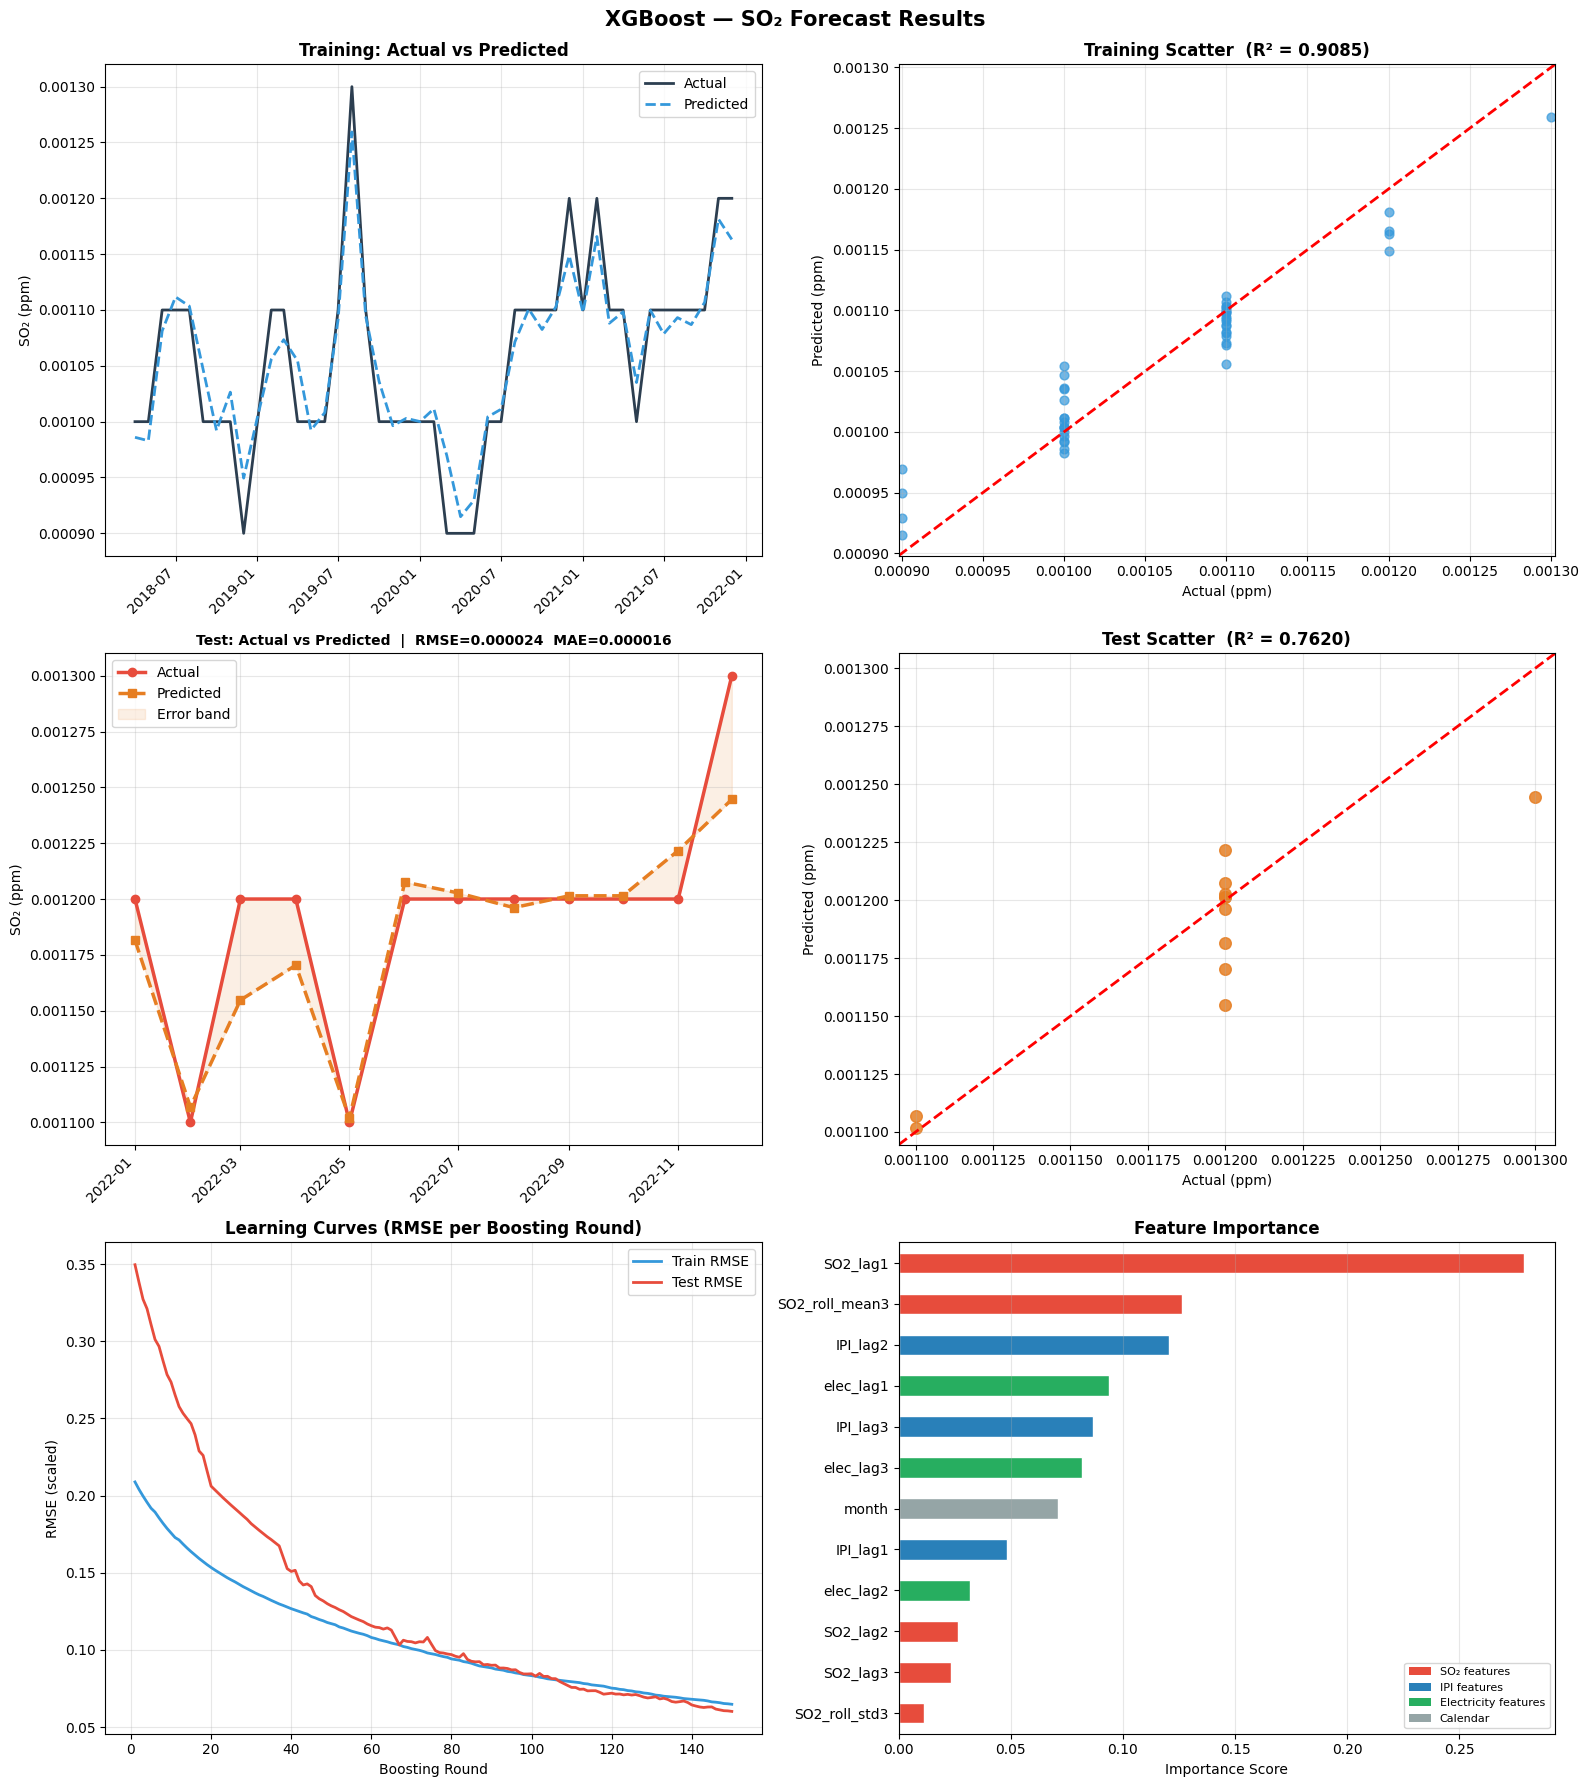

Figure displayed inline only; no PNG written to disk.


In [80]:
residuals   = y_act_te - y_pred_te
evals       = model.evals_result()
tr_curve    = evals['validation_0']['rmse']
te_curve    = evals['validation_1']['rmse']
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
imp_colors  = ['#e74c3c' if 'SO2'  in f else
               '#2980b9' if 'IPI'  in f else
               '#27ae60' if 'elec' in f else '#95a5a6'
               for f in importances.index]

fig = plt.figure(figsize=(16, 18))
fig.suptitle('XGBoost — SO₂ Forecast Results', fontsize=15, fontweight='bold', y=0.99)

# ① Training: time-series
ax1 = fig.add_subplot(3, 2, 1)
ax1.plot(X_tr.index, y_act_tr,  lw=2, color='#2c3e50', label='Actual')
ax1.plot(X_tr.index, y_pred_tr, lw=2, color='#3498db', ls='--', label='Predicted')
ax1.set_title('Training: Actual vs Predicted', fontweight='bold')
ax1.set_ylabel('SO₂ (ppm)'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ② Training: scatter
ax2 = fig.add_subplot(3, 2, 2)
ax2.scatter(y_act_tr, y_pred_tr, alpha=0.7, s=40, color='#3498db')
lim = [min(y_act_tr.min(), y_pred_tr.min())*0.998,
       max(y_act_tr.max(), y_pred_tr.max())*1.002]
ax2.plot(lim, lim, 'r--', lw=2)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_title(f'Training Scatter  (R² = {tr_r2:.4f})', fontweight='bold')
ax2.set_xlabel('Actual (ppm)'); ax2.set_ylabel('Predicted (ppm)'); ax2.grid(alpha=0.3)

# ③ Test: time-series
ax3 = fig.add_subplot(3, 2, 3)
ax3.plot(X_te.index, y_act_te,  lw=2.5, color='#e74c3c', marker='o', ms=6, label='Actual')
ax3.plot(X_te.index, y_pred_te, lw=2.5, color='#e67e22', ls='--', marker='s', ms=6, label='Predicted')
ax3.fill_between(X_te.index, y_act_te, y_pred_te, alpha=0.12, color='#e67e22', label='Error band')
ax3.set_title(f'Test: Actual vs Predicted  |  RMSE={te_rmse:.6f}  MAE={te_mae:.6f}',
              fontweight='bold', fontsize=10)
ax3.set_ylabel('SO₂ (ppm)'); ax3.legend(); ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ④ Test: scatter
ax4 = fig.add_subplot(3, 2, 4)
ax4.scatter(y_act_te, y_pred_te, alpha=0.85, s=70, color='#e67e22')
lim2 = [min(y_act_te.min(), y_pred_te.min())*0.995,
        max(y_act_te.max(), y_pred_te.max())*1.005]
ax4.plot(lim2, lim2, 'r--', lw=2)
ax4.set_xlim(lim2); ax4.set_ylim(lim2)
ax4.set_title(f'Test Scatter  (R² = {te_r2:.4f})', fontweight='bold')
ax4.set_xlabel('Actual (ppm)'); ax4.set_ylabel('Predicted (ppm)'); ax4.grid(alpha=0.3)

# ⑤ Learning curves
ax5 = fig.add_subplot(3, 2, 5)
ax5.plot(range(1, len(tr_curve)+1), tr_curve, color='#3498db', lw=2, label='Train RMSE')
ax5.plot(range(1, len(te_curve)+1), te_curve, color='#e74c3c', lw=2, label='Test RMSE')
ax5.set_title('Learning Curves (RMSE per Boosting Round)', fontweight='bold')
ax5.set_xlabel('Boosting Round'); ax5.set_ylabel('RMSE (scaled)')
ax5.legend(); ax5.grid(alpha=0.3)

# ⑥ Feature importance
ax6 = fig.add_subplot(3, 2, 6)
importances.plot(kind='barh', ax=ax6, color=imp_colors, edgecolor='white')
ax6.set_title('Feature Importance', fontweight='bold')
ax6.set_xlabel('Importance Score')
ax6.legend(handles=[
    Patch(facecolor='#e74c3c', label='SO₂ features'),
    Patch(facecolor='#2980b9', label='IPI features'),
    Patch(facecolor='#27ae60', label='Electricity features'),
    Patch(facecolor='#95a5a6', label='Calendar'),
], loc='lower right', fontsize=8)
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure displayed inline only; no PNG written to disk.')


## 12 — Results Summary

In [81]:
print('='*55)
print('      XGBOOST — FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Train RMSE : {tr_rmse:.6f}    Test RMSE : {te_rmse:.6f}')
print(f'  Train MAE  : {tr_mae:.6f}    Test MAE  : {te_mae:.6f}')
print(f'  Train R²   : {tr_r2:.4f}        Test R²   : {te_r2:.4f}')
print('='*55)
print(f'  N_LAGS={N_LAGS}  |  Train={len(X_tr)} pts  |  Test={len(X_te)} pts')
print('\n  Hyperparameters used:')
for k, v in best_params.items():
    print(f'    {k:<20}: {v}')
print('\n  Top 5 features by importance:')
for feat, score in importances.tail(5).iloc[::-1].items():
    print(f'    {feat:<22}: {score:.4f}')


      XGBOOST — FINAL RESULTS SUMMARY
  Train RMSE : 0.000026    Test RMSE : 0.000024
  Train MAE  : 0.000019    Test MAE  : 0.000016
  Train R²   : 0.9085        Test R²   : 0.7620
  N_LAGS=3  |  Train=45 pts  |  Test=12 pts

  Hyperparameters used:
    n_estimators        : 150
    max_depth           : 2
    learning_rate       : 0.05
    subsample           : 1.0
    colsample_bytree    : 0.8
    reg_lambda          : 1
    min_child_weight    : 1

  Top 5 features by importance:
    SO2_lag1              : 0.2787
    SO2_roll_mean3        : 0.1264
    IPI_lag2              : 0.1206
    elec_lag1             : 0.0936
    IPI_lag3              : 0.0867
